# Conditional Autoencoder for US Firm Characteristics

This notebook tests whether nonlinear characteristic-conditioned factor loadings improve
one-month cross-sectional return forecasts.

**Learning objectives**

- Fit a conditional autoencoder through sealed walk-forward folds.
- Distinguish physical training checkpoints from validation-selected aliases.
- Evaluate checkpoint stability with daily rank IC and HAC uncertainty.

**Book reference:** Chapter 14, latent factor models and conditional autoencoders.

**Prerequisites:** `03_financial_features`, `04_evaluation`, and the split contract used by
`05_linear` through `07_tabular_dl`.

In [1]:
"""US firm characteristics CAE case-study run via the shared latent-factor library path."""

import warnings

import matplotlib.pyplot as plt
import polars as pl
from IPython.display import Markdown, display

from case_studies.utils import registry
from case_studies.utils.latent_factors.case_study import (
    configured_models,
    load_case_study_context,
    run_case_study_model,
)
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, add_message_title

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "us_firm_characteristics"
PRIMARY_LABEL = ""
MAX_SYMBOLS = 0
N_FACTORS = 5
N_EPOCHS = 50
USE_CACHE = True
FORCE_RETRAIN = False
MAX_FOLDS = 0
MAX_VARIANT_LABELS = -1
USE_MACRO = False
MODEL_NAME = "cae"
SEED = 42

## Load the dated modeling surface

The shared context fixes the feature order, ten expanding-window splits, continuous target, and
explicit CUDA runtime. Persistent firm identifiers keep each company stable across months.

In [3]:
set_global_seeds(SEED)
context = load_case_study_context(
    CASE_STUDY_ID,
    primary_label=PRIMARY_LABEL,
    max_symbols=MAX_SYMBOLS,
    max_folds=MAX_FOLDS,
    max_variant_labels=MAX_VARIANT_LABELS,
    use_macro=USE_MACRO,
)
if MODEL_NAME not in configured_models(context):
    raise ValueError(f"{MODEL_NAME!r} is not configured for {CASE_STUDY_ID}")

print(f"Observations: {len(context.dataset):,}")
print(f"Characteristics: {len(context.feature_names)}")
print(f"Walk-forward folds: {len(context.splits)}")
print(f"Runtime: {context.device}, deterministic={context.deterministic_algorithms}")

Observations: 804,530
Characteristics: 57
Walk-forward folds: 10
Runtime: cuda, deterministic=True


## Run or replay walk-forward training

The fixed reporting rule uses the final physical epoch. Checkpoint zero is not part of the
registry surface because the model library reserves it for a state selected with validation loss.
Cached execution requires an exact match on input digest, split boundaries, runtime, checkpoint
coverage, prediction keys, and reconstructed daily IC metrics.

In [4]:
result = run_case_study_model(
    context,
    model_name=MODEL_NAME,
    notebook="08b_conditional_autoencoder",
    n_factors=N_FACTORS,
    n_epochs=N_EPOCHS,
    use_cache=USE_CACHE,
    force_retrain=FORCE_RETRAIN,
)
model_result = result["model_results"][0]
fold_metrics = result["fold_metrics"][MODEL_NAME]

print(f"Reporting epoch: {model_result['best_epoch']}")
print(f"Mean daily rank IC: {model_result['mean_ic']:+.4f}")
print(f"Completed folds: {model_result['n_folds']}")

Latent factor CV: 1 models × 10 folds
Log file: $ML4T_OUTPUT_DIR/us_firm_characteristics/run_log/latent_factors.log
Scoring: dates=rebalance cadence=monthly_month_end step=1 checkpoint_selection=fixed reporting_epoch=last


  cae: loaded exact registry cohort (IC=-0.0396)
  Best: cae (IC=-0.0396)
Reporting epoch: 50
Mean daily rank IC: -0.0396
Completed folds: 10


## Confirm the registered physical checkpoint surface

The registry is the reader-facing source of truth. The query below binds the displayed curve to
the one complete CAE training identity produced by this notebook.

In [5]:
training_runs = registry.load_training_runs(
    CASE_STUDY_ID,
    family="latent_factors",
    label=context.primary_label,
).filter(
    (pl.col("config_name") == MODEL_NAME) & (pl.col("entry_point") == "08b_conditional_autoencoder")
)
if training_runs.height != 1:
    raise ValueError(f"Expected one complete CAE identity, found {training_runs.height}")
training_hash = training_runs["training_hash"][0]

prediction_sets = registry.load_prediction_sets(
    CASE_STUDY_ID,
    training_hash=training_hash,
    split="validation",
)
prediction_metrics = registry.load_prediction_metrics(CASE_STUDY_ID)
checkpoint_summary = (
    prediction_sets.join(prediction_metrics, on="prediction_hash", how="inner")
    .sort("checkpoint_value")
    .select(
        pl.col("checkpoint_value").alias("epoch"),
        "ic_mean_daily",
        "ic_ci_lo",
        "ic_ci_hi",
        "ic_p_hac",
        "ic_n_days",
    )
)
checkpoint_summary

epoch,ic_mean_daily,ic_ci_lo,ic_ci_hi,ic_p_hac,ic_n_days
i64,f64,f64,f64,f64,f64
5,-0.045314,-0.068034,-0.022593,0.000138,110.0
10,-0.030129,-0.051573,-0.008686,0.006318,110.0
15,-0.034041,-0.057176,-0.010906,0.004301,110.0
20,-0.037638,-0.062416,-0.01286,0.00324,110.0
25,-0.03298,-0.05379,-0.01217,0.002167,110.0
30,-0.039353,-0.062196,-0.016511,0.000898,110.0
35,-0.0331,-0.05892,-0.007281,0.012466,110.0
40,-0.040717,-0.065333,-0.0161,0.001402,110.0
45,-0.032836,-0.055098,-0.010574,0.004212,110.0


## Training longer does not rescue the CAE signal

Fold dispersion shows whether a mean result reflects a stable cross-period effect. The final
epoch is fixed before inspecting its IC, while the full curve remains diagnostic.

In [6]:
curve = (
    fold_metrics.group_by("epoch")
    .agg(
        pl.col("ic_mean").mean().alias("mean_ic"),
        pl.col("ic_mean").std().alias("fold_std"),
    )
    .sort("epoch")
)
selected_epoch = int(model_result["best_epoch"])
selected = curve.filter(pl.col("epoch") == selected_epoch).row(0, named=True)

The path below marks the predeclared final checkpoint and uses fold dispersion to show how much
the cross-period estimates vary around each mean.

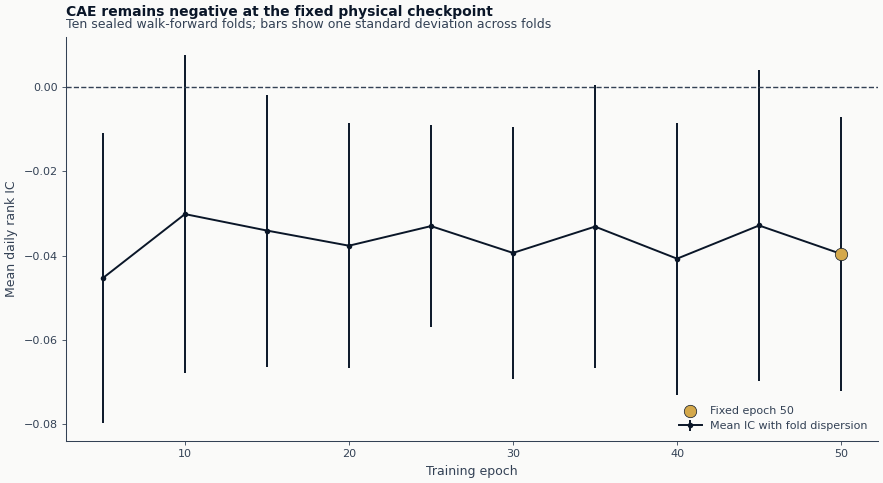

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(
    curve["epoch"],
    curve["mean_ic"],
    yerr=curve["fold_std"],
    color=COLORS["blue"],
    marker="o",
    capsize=3,
    label="Mean IC with fold dispersion",
)
ax.scatter(
    [selected_epoch],
    [selected["mean_ic"]],
    color=COLORS["amber"],
    edgecolor=COLORS["blue"],
    s=80,
    zorder=3,
    label=f"Fixed epoch {selected_epoch}",
)
ax.axhline(0, color=COLORS["neutral"], linewidth=1, linestyle="--")
ax.set(xlabel="Training epoch", ylabel="Mean daily rank IC")
ax.legend(loc="best")
direction = "negative" if selected["mean_ic"] < 0 else "positive"
add_message_title(
    ax,
    f"CAE remains {direction} at the fixed physical checkpoint",
    subtitle="Ten sealed walk-forward folds; bars show one standard deviation across folds",
)
fig.tight_layout()
fig.show()

## Takeaways

The final checkpoint and its HAC interval determine the interpretation; no checkpoint is chosen
after inspecting validation IC.

In [8]:
fixed = checkpoint_summary.filter(pl.col("epoch") == selected_epoch).row(0, named=True)
interval_verdict = "excludes" if fixed["ic_ci_lo"] * fixed["ic_ci_hi"] > 0 else "includes"
display(
    Markdown(
        f"""
- The fixed epoch-{selected_epoch} CAE reaches daily rank IC **{fixed["ic_mean_daily"]:+.4f}**
  across **{int(fixed["ic_n_days"])}** validation months.
- Its HAC 95% interval is **[{fixed["ic_ci_lo"]:+.4f}, {fixed["ic_ci_hi"]:+.4f}]** and
  {interval_verdict} zero, so the model does not establish a stable forecasting edge.
- The checkpoint path stays negative on average, indicating that additional reconstruction
  training does not repair the weak forward-return mapping.
- `08c_stochastic_discount_factor` next tests an explicitly asset-pricing-driven latent model;
  Chapter 14 explains why reconstruction and pricing objectives can imply different signals.
"""
    )
)


- The fixed epoch-50 CAE reaches daily rank IC **-0.0396**
  across **110** validation months.
- Its HAC 95% interval is **[-0.0654, -0.0137]** and
  excludes zero, so the model does not establish a stable forecasting edge.
- The checkpoint path stays negative on average, indicating that additional reconstruction
  training does not repair the weak forward-return mapping.
- `08c_stochastic_discount_factor` next tests an explicitly asset-pricing-driven latent model;
  Chapter 14 explains why reconstruction and pricing objectives can imply different signals.
